# 🐄 EfficientNet Fine-Tuning and Split Comparison Notebook
This notebook refines the Indigenous Cattle Breed Classifier using EfficientNet, evaluates different train/validation/test splits, and supports URL-based inference.

In [2]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import random, math, os
from collections import defaultdict
from PIL import Image
import requests
from io import BytesIO

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Mounted at /content/drive
Using device: cuda


In [3]:
# --- Dataset Paths ---
ROOT = '/content/drive/MyDrive/cattle_images_whole'

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

def get_transforms(img_size=224, train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
        ])

dataset = datasets.ImageFolder(ROOT, transform=get_transforms(train=True))
print('Classes:', dataset.classes)
print('Total samples:', len(dataset))


Classes: ['Alambadi', 'Amritmahal', 'Ayrshire', 'Banni', 'Bargur', 'Bhadawari', 'Brown_Swiss', 'Dangi', 'Deoni', 'Gir', 'Guernsey', 'Hallikar', 'Hariana', 'Holstein_Friesian', 'Jaffrabadi', 'Jersey', 'Kangayam', 'Kankrej', 'Kasargod', 'Kenkatha', 'Kherigarh', 'Khillari', 'Krishna_Valley', 'Malnad_gidda', 'Mehsana', 'Murrah', 'Nagori', 'Nagpuri', 'Nili_Ravi', 'Nimari', 'Ongole', 'Pulikulam', 'Rathi', 'Red_Dane', 'Red_Sindhi', 'Sahiwal', 'Surti', 'Tharparkar', 'Toda', 'Umblachery', 'Vechur']
Total samples: 5712


In [4]:
def train_test_validation_split(dataset, validation_split_fraction=0.1, test_split_fraction=0.1, seed=42):
    random.seed(seed)
    label_to_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        label_to_indices[label].append(idx)

    train_idx, val_idx, test_idx = [], [], []

    for label, indices in label_to_indices.items():
        n = len(indices)
        n_test = max(1, int(math.floor(test_split_fraction * n)))
        n_val = max(1, int(math.floor(validation_split_fraction * n)))
        n_train = n - n_val - n_test

        shuffled = indices[:]
        random.shuffle(shuffled)
        train_idx.extend(shuffled[:n_train])
        val_idx.extend(shuffled[n_train:n_train+n_val])
        test_idx.extend(shuffled[n_train+n_val:n_train+n_val+n_test])

    return Subset(dataset, train_idx), Subset(dataset, val_idx), Subset(dataset, test_idx)



=== Split: Val=10%, Test=10% ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 153MB/s]


Epoch 1: Train Acc=0.251, Val Acc=0.437
Epoch 2: Train Acc=0.436, Val Acc=0.523
Epoch 3: Train Acc=0.535, Val Acc=0.581

=== Split: Val=15%, Test=15% ===
Epoch 1: Train Acc=0.231, Val Acc=0.373
Epoch 2: Train Acc=0.406, Val Acc=0.512
Epoch 3: Train Acc=0.536, Val Acc=0.568

=== Split: Val=20%, Test=20% ===
Epoch 1: Train Acc=0.233, Val Acc=0.378
Epoch 2: Train Acc=0.408, Val Acc=0.492
Epoch 3: Train Acc=0.502, Val Acc=0.543


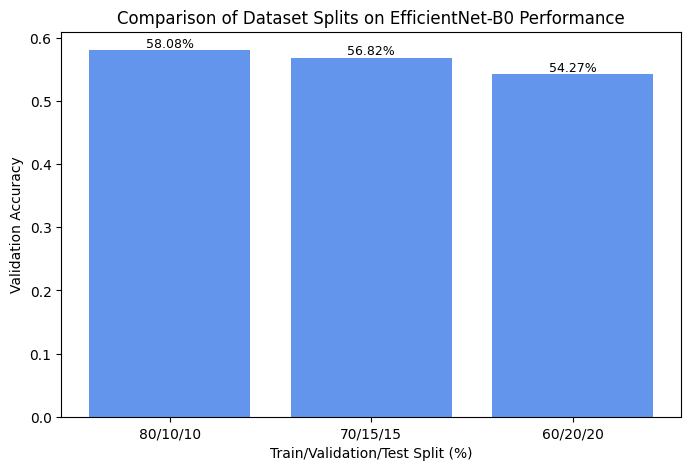


Summary of Split Performances:
80/10/10 split -> 58.08% Validation Accuracy
70/15/15 split -> 56.82% Validation Accuracy
60/20/20 split -> 54.27% Validation Accuracy


In [7]:
split_results = {}   #DONOTRUN
split_configs = [(0.1, 0.1), (0.15, 0.15), (0.2, 0.2)]

for val_split, test_split in split_configs:
    print(f"\n=== Split: Val={val_split*100:.0f}%, Test={test_split*100:.0f}% ===")

    train_set, val_set, test_set = train_test_validation_split(dataset, val_split, test_split)
    train_loader = DataLoader(train_set, batch_size=8, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=8, shuffle=False, num_workers=2)

    model = models.efficientnet_b0(weights='IMAGENET1K_V1')
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(dataset.classes))
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    best_val_acc = 0.0

    for epoch in range(3):  # quick comparison runs
        model.train()
        correct, total = 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total
        best_val_acc = max(best_val_acc, val_acc)
        print(f"Epoch {epoch+1}: Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}")

    split_results[f"{int((1-val_split-test_split)*100)}/{int(val_split*100)}/{int(test_split*100)}"] = best_val_acc

plt.figure(figsize=(8,5))
splits = list(split_results.keys())
accs = list(split_results.values())
plt.bar(splits, accs, color='cornflowerblue')
plt.xlabel('Train/Validation/Test Split (%)')
plt.ylabel('Validation Accuracy')
plt.title('Comparison of Dataset Splits on EfficientNet-B0 Performance')
for i, v in enumerate(accs):
    plt.text(i, v + 0.005, f"{v*100:.2f}%", ha='center', fontsize=9)
plt.show()

print("\nSummary of Split Performances:")
for k, v in split_results.items():
    print(f"{k} split -> {v*100:.2f}% Validation Accuracy")


In [5]:
MODEL_PATH = '/content/drive/MyDrive/efficientnet_b0_best.pth'

model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(dataset.classes))

checkpoint = torch.load(MODEL_PATH, map_location=device)

# Handle both possible save formats
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)  # direct state_dict

model.to(device)
model.eval()

print("✅ Loaded model checkpoint successfully from:", MODEL_PATH)


✅ Loaded model checkpoint successfully from: /content/drive/MyDrive/efficientnet_b0_best.pth


In [6]:
# ✅ Unfreeze last few blocks and classifier for fine-tuning
for name, param in model.named_parameters():
    if any(x in name for x in ["blocks.2", "blocks.3", "blocks.4", "blocks.5", "blocks.6", "conv_head", "classifier"]):
        param.requires_grad = True
    else:
        param.requires_grad = False

# Check how many parameters are trainable now
trainable_params = [name for name, param in model.named_parameters() if param.requires_grad]
print(f"Trainable layers: {len(trainable_params)}")
for n in trainable_params[:10]:
    print("  ", n)


Trainable layers: 2
   classifier.1.weight
   classifier.1.bias


In [32]:
import torch.optim as optim   ###TRAINING PARAMETERS###
import torch.nn as nn

# ✅ Compute class weights (optional but helps for unbalanced datasets)
from collections import Counter

# count samples per class
class_counts = Counter([label for _, label in dataset.samples])
num_classes = len(class_counts)
total_samples = sum(class_counts.values())
class_weights = [total_samples / class_counts[i] for i in range(num_classes)]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# ✅ Define optimizer, scheduler, and improved loss
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5,            # ⬇ slightly lower LR for stable fine-tuning
    weight_decay=5e-5   # ⬇ gentle regularization
)

# ✅ Cosine Annealing for smoother learning rate decay
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=25,   # number of epochs per cycle
    eta_min=1e-6
)

print("Optimizer, scheduler, and loss function configured successfully.")


Optimizer, scheduler, and loss function configured successfully.


In [7]:
len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset)


NameError: name 'train_loader' is not defined

In [8]:
# --- Create Data Splits and DataLoaders ---
train_set, val_set, test_set = train_test_validation_split(dataset, validation_split_fraction=0.1, test_split_fraction=0.1)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_set)} | Val samples: {len(val_set)} | Test samples: {len(test_set)}")


Train samples: 4610 | Val samples: 551 | Test samples: 551


In [34]:
# --- Update transforms for train/val/test sets ---
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Reassign transforms dynamically (no need to re-split)
train_set.dataset.transform = train_transform
val_set.dataset.transform = val_test_transform
test_set.dataset.transform = val_test_transform

print("✅ Updated data augmentations applied to training set.")


✅ Updated data augmentations applied to training set.


In [35]:
import os
from tqdm import tqdm

NUM_EPOCHS = 25
best_val_acc = 0.0
SAVE_PATH = "efficientnet_b0_finetuned.pth"

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Acc: {train_acc:.3f}, Val Acc: {val_acc:.3f}")

    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': best_val_acc
        }, SAVE_PATH)
        print(f"✅ New best model saved at epoch {epoch+1} with Val Acc: {val_acc*100:.2f}%")

print(f"Best Validation Accuracy After Fine-Tuning: {best_val_acc*100:.2f}%")


Epoch 1/25 - Training: 100%|██████████| 289/289 [00:40<00:00,  7.09it/s]
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 1/25 - Train Acc: 0.675, Val Acc: 0.597
✅ New best model saved at epoch 1 with Val Acc: 59.71%


Epoch 2/25 - Training: 100%|██████████| 289/289 [00:40<00:00,  7.07it/s]


Epoch 2/25 - Train Acc: 0.677, Val Acc: 0.588


Epoch 3/25 - Training: 100%|██████████| 289/289 [00:41<00:00,  7.04it/s]


...

Epoch 23/25 - Train Acc: 0.692, Val Acc: 0.590


Epoch 24/25 - Training: 100%|██████████| 289/289 [00:41<00:00,  7.03it/s]


Epoch 24/25 - Train Acc: 0.692, Val Acc: 0.597


Epoch 25/25 - Training: 100%|██████████| 289/289 [00:40<00:00,  7.06it/s]


Epoch 25/25 - Train Acc: 0.694, Val Acc: 0.595
Best Validation Accuracy After Fine-Tuning: 59.89%


In [18]:
# ✅ Save model state and optimizer for later use in Drive
SAVE_PATH = '/content/drive/MyDrive/model_checkpoint.pth'

save_state = {
    'epoch': epoch + 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc': best_val_acc,
}

torch.save(save_state, SAVE_PATH)
print(f"✅ Model checkpoint saved successfully to: {SAVE_PATH}")


✅ Model checkpoint saved successfully to: /content/drive/MyDrive/model_checkpoint.pth


In [12]:
!ls -lh /content/drive/MyDrive/efficientnet_b0_finetuned.pth


ls: cannot access '/content/drive/MyDrive/efficientnet_b0_finetuned.pth': No such file or directory


In [19]:
# Move the saved model from Colab to Drive
!cp efficientnet_b0_finetuned.pth /content/drive/MyDrive/

# Confirm it's there
!ls -lh /content/drive/MyDrive/efficientnet_b0_finetuned.pth


-rw------- 1 root root 17M Oct 29 18:37 /content/drive/MyDrive/efficientnet_b0_finetuned.pth


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                   precision    recall  f1-score   support

         Alambadi       0.71      0.56      0.62         9
       Amritmahal       0.33      0.22      0.27         9
         Ayrshire       0.57      0.57      0.57        23
            Banni       0.50      0.56      0.53         9
           Bargur       0.64      0.78      0.70         9
        Bhadawari       0.25      0.38      0.30         8
      Brown_Swiss       0.55      0.50      0.52        22
            Dangi       0.50      0.88      0.64         8
            Deoni       0.64      0.78      0.70         9
              Gir       0.85      0.50      0.63        34
         Guernsey       0.43      0.27      0.33        11
         Hallikar       0.71      0.56      0.62        18
          Hariana       0.38      0.25      0.30        12
Holstein_Friesian       0.87      0.81      0.84        32
       Jaffrabadi       0.38      0.33      0.35         9
           Jersey       0.58      0.74      0.65       

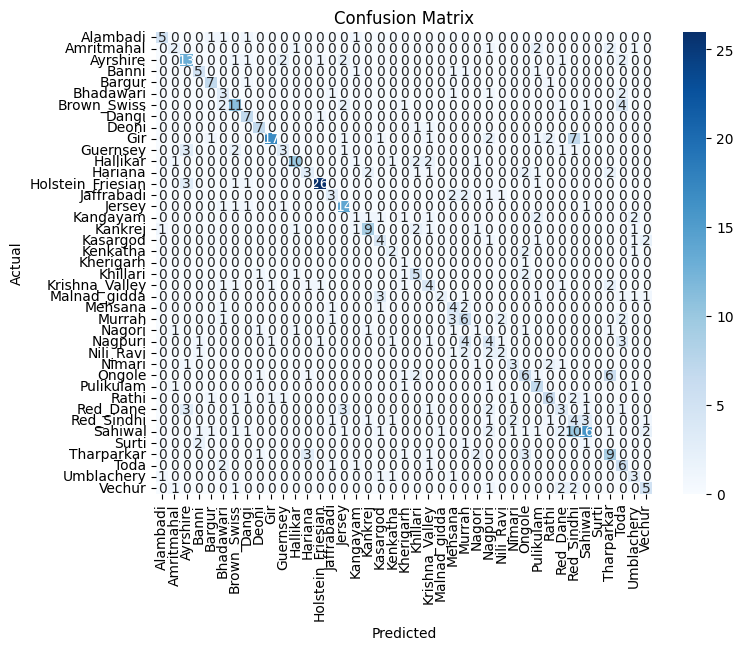

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# Reload the fine-tuned model
checkpoint = torch.load("/content/drive/MyDrive/efficientnet_b0_finetuned.pth", map_location=torch.device('cpu'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Create test loader if not done
_, _, test_set = train_test_validation_split(dataset, 0.1, 0.1)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

# --- Evaluation ---
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Metrics
print(classification_report(y_true, y_pred, target_names=dataset.classes))
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [11]:
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(val_acc_list, label='Validation Accuracy')
plt.legend()
plt.show()


NameError: name 'train_acc_list' is not defined

Predicted: Gir (99.31%)


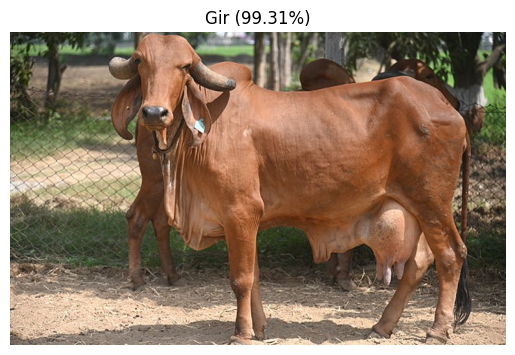

In [11]:
def predict_from_url(model, url, class_names, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content)).convert('RGB')
    except Exception as e:
        print(f"Error loading image: {e}")
        return

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = F.softmax(output, dim=1)
        top_prob, top_class = torch.max(probs, 1)

    print(f"Predicted: {class_names[top_class.item()]} ({top_prob.item()*100:.2f}%)")
    plt.imshow(img)
    plt.title(f"{class_names[top_class.item()]} ({top_prob.item()*100:.2f}%)")
    plt.axis("off")
    plt.show()

# Example usage
predict_from_url(model, "https://girorganic.com/cdn/shop/articles/what-is-gir-cow-453725.jpg?v=1673547600", dataset.classes)
